In [1]:
import os
import requests
from io import BytesIO
import pandas as pd
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# 1. Configurar el estilo visual (estilo Economist/Colorblind)
sns.set_theme(style='whitegrid', palette='colorblind')

### **Paso A: Importación de Librerías y Carga de la Imagen**

In [2]:
def cargar_y_preprocesar(ruta_o_url, max_size=(150, 150)):
    """
    Carga una imagen (local o URL), la reduce de tamaño para acelerar K-Means
    y la normaliza al rango [0, 1] aplanando las dimensiones espaciales.
    """
    if ruta_o_url.startswith('http'):
        response = requests.get(ruta_o_url)
        img = Image.open(BytesIO(response.content))
    else:
        if not os.path.exists(ruta_o_url):
            # Creamos un bonito diseño geométrico de prueba si no existe el archivo local
            img = Image.new('RGB', (300, 300), color='#1A252F')
            draw = ImageDraw.Draw(img)
            draw.ellipse([50, 50, 250, 250], fill='#E74C3C')      # Círculo Rojo
            draw.rectangle([100, 100, 200, 200], fill='#3498DB')  # Cuadrado Azul
            draw.polygon([(150, 60), (190, 140), (110, 140)], fill='#2ECC71') # Triángulo Verde
        else:
            img = Image.open(ruta_o_url)

    img = img.convert('RGB')
    img.thumbnail(max_size)  # Reducción proporcional inteligente
    
    data = np.array(img) / 255.0
    w, h, d = data.shape
    pixels = data.reshape((w * h, d))    
    return img, pixels, (w, h, d)

### **Paso B: Aplicación del Método del Codo**
Entrenamos múltiples modelos de K-Means variando \\(K\\) de 2 a 10 para registrar la inercia de cada uno:

In [3]:
# =====================================================================
# ALGORITMO DE OPTIMIZACIÓN GEOMÉTRICA (MÉTODO DEL CODO)
# =====================================================================
def encontrar_codo(k_values, inertias):
    """
    Encuentra aproximadamente el punto de codo utilizando distancia geométrica
    sobre ejes normalizados mediante Min-Max scaling.
    """
    x = np.array(list(k_values), dtype=float)
    y = np.array(inertias, dtype=float)

    # Tu excelente normalización Min-Max para equilibrar las escalas de ambos ejes
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())

    punto_inicio = np.array([x_norm[0], y_norm[0]])
    punto_final = np.array([x_norm[-1], y_norm[-1]])

    # Vector director de la recta secante
    vector_recta = punto_final - punto_inicio

    distancias = []
    for i in range(len(x_norm)):
        punto_actual = np.array([x_norm[i], y_norm[i]])
        vector_punto = punto_actual - punto_inicio
        
        # Producto cruz manual en 2D (Fórmula matemática directa compatible con NumPy 2.0+)
        num = np.abs(vector_recta[0] * vector_punto[1] - vector_recta[1] * vector_punto[0])
        den = np.linalg.norm(vector_recta)
        
        distancias.append(num / den)

    # Índice del punto con la distancia perpendicular máxima
    indice_codo = np.argmax(distancias)

    return int(x[indice_codo]), distancias



### **Paso C: Reconstrucción de la Imagen con el K Óptimo**
Una vez identificado el "codo" en la gráfica (supongamos que \\(K=5\\)), entrenamos el modelo final y reemplazamos el color original de cada píxel por el de su centroide correspondiente:

=== TABLA DE EXPLORACIÓN DE K ===
 K Inercia Mejora %
 2  856.68      NaN
 3  340.30   60.28%
 4  263.55   22.55%
 5  189.08   28.26%
 6  152.34   19.43%
 7  125.56   17.58%
 8  105.92   15.64%
 9   95.46    9.87%
10   86.45    9.44%


-> El K Óptimo matemáticamente es: 3

=== PALETA DE COLORES CROMÁTICOS (CENTROIDES) ===
Clúster 1: Hex #375451 -> RGB (np.int64(55), np.int64(84), np.int64(81))
Clúster 2: Hex #D4A46C -> RGB (np.int64(212), np.int64(164), np.int64(108))
Clúster 3: Hex #0B0C1B -> RGB (np.int64(11), np.int64(12), np.int64(27))


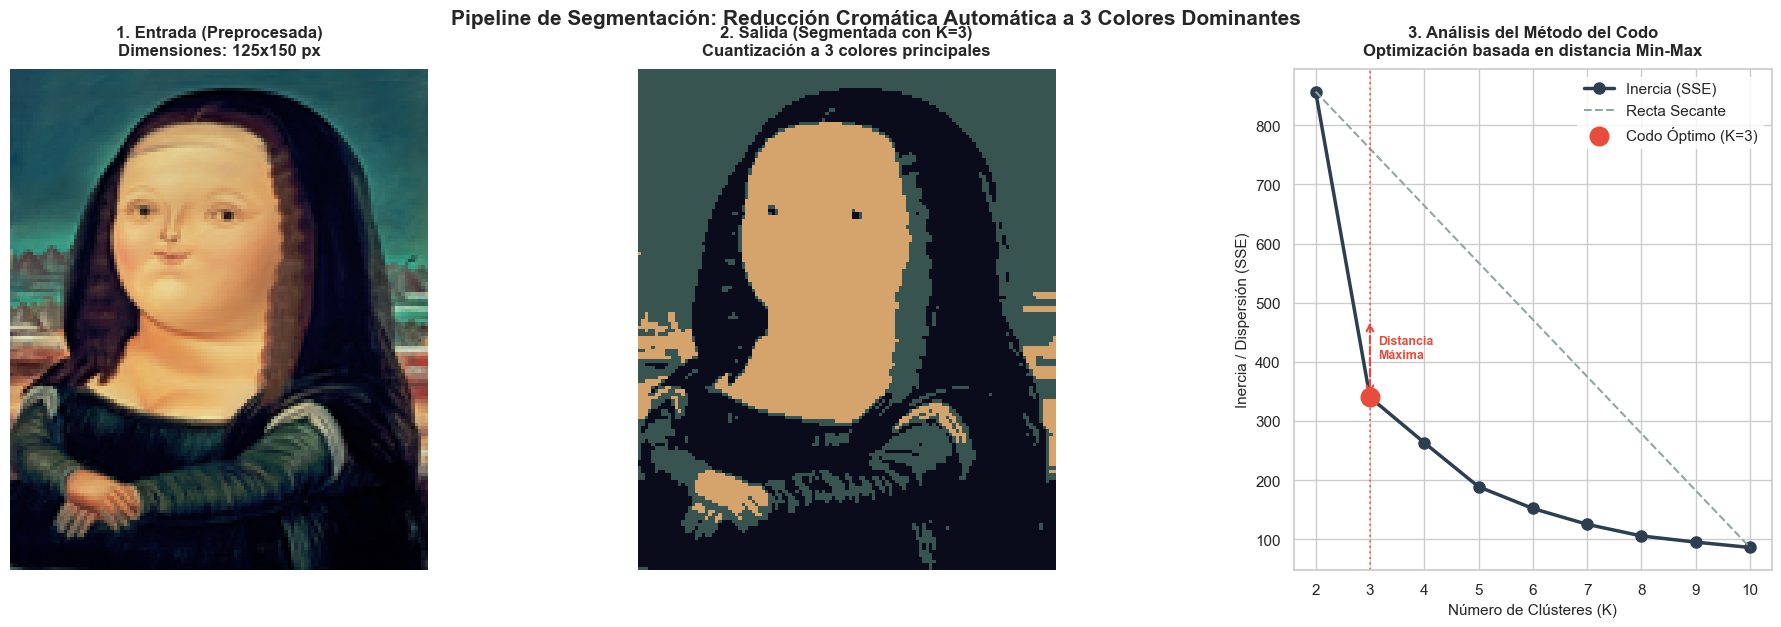

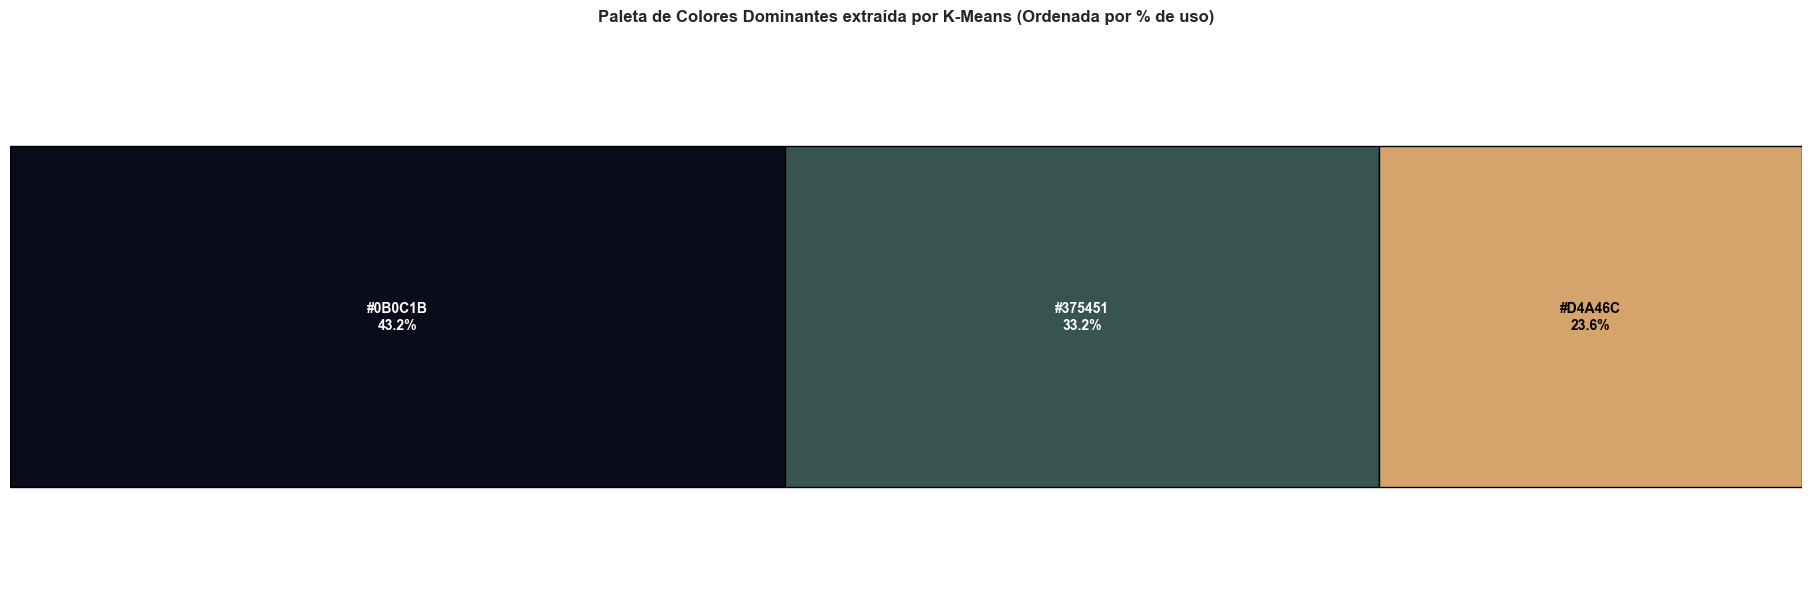

In [4]:
# =====================================================================
# PIPELINE DE PROCESAMIENTO
# =====================================================================
ruta_imagen="https://www.singulart.com/blog/wp-content/uploads/2024/02/Mona-Lisa-Age-Twelve-1-1140x1363.jpg"
# Carga la imagen (puedes reemplazar por la ruta local de tu imagen, ej: "foto.jpg")
img_entrada, X_pixeles, (w, h, d) = cargar_y_preprocesar(ruta_imagen, max_size=(150, 150))

# A. Bucle de exploración de K (2 a 10) - Optimizado (ejecuta .fit() una única vez)
inercias = []
rango_k = list(range(2, 11))

for k in rango_k:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_pixeles)
    inercias.append(kmeans.inertia_)

# B. Cálculo de la inercia y porcentajes de mejora
resultados = []
for i, k in enumerate(rango_k):
    inercia_actual = inercias[i]
    if i == 0:
        mejora = np.nan
    else:
        inercia_anterior = inercias[i - 1]
        mejora = ((inercia_anterior - inercia_actual) / inercia_anterior) * 100
        
    resultados.append({
        "K": k,
        "Inercia": inercia_actual,
        "Mejora %": mejora
    })

df_resultados = pd.DataFrame(resultados)
print("=== TABLA DE EXPLORACIÓN DE K ===")
print(df_resultados.to_string(index=False, formatters={'Inercia': '{:,.2f}'.format, 'Mejora %': '{:.2f}%'.format}))
print("\n" + "="*45 + "\n")

# C. Encontrar el K Óptimo matemáticamente
k_opt, distancias = encontrar_codo(df_resultados["K"], df_resultados["Inercia"])
idx_opt = rango_k.index(k_opt)
print(f"-> El K Óptimo matemáticamente es: {k_opt}\n")

# D. Entrenamiento del modelo K-Means definitivo
kmeans_definitivo = KMeans(n_clusters=k_opt, init='k-means++', random_state=42, n_init=10)
labels = kmeans_definitivo.fit_predict(X_pixeles)
centroids = kmeans_definitivo.cluster_centers_

# E. Reconstrucción de la imagen segmentada
pixels_segmented = centroids[labels]
img_salida_arr = (pixels_segmented.reshape((w, h, d)) * 255).astype(np.uint8)
img_salida = Image.fromarray(img_salida_arr)

# F. Extracción limpia de la paleta de colores dominantes
colores_rgb = (centroids * 255).astype(int)
colores_hex = [f"#{r:02x}{g:02x}{b:02x}" for r, g, b in colores_rgb]

print("=== PALETA DE COLORES CROMÁTICOS (CENTROIDES) ===")
for i, hex_code in enumerate(colores_hex):
    print(f"Clúster {i+1}: Hex {hex_code.upper()} -> RGB {tuple(colores_rgb[i])}")


# =====================================================================
# GRAFICACIÓN DEL DASHBOARD DE TRES PANELES (LAYOUT PROFESIONAL)
# =====================================================================
# Usamos layout="constrained" para eliminar por completo la advertencia de tight_layout
fig = plt.figure(figsize=(18, 6), layout="constrained")
gs = fig.add_gridspec(1, 3, wspace=0.25)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# Panel 1: Entrada original preprocesada
ax1.imshow(img_entrada)
ax1.set_title(f"1. Entrada (Preprocesada)\nDimensiones: {img_entrada.size[0]}x{img_entrada.size[1]} px", 
             fontsize=12, fontweight='bold', pad=10)
ax1.axis('off')

# Panel 2: Imagen segmentada resultante
ax2.imshow(img_salida)
ax2.set_title(f"2. Salida (Segmentada con K={k_opt})\nCuantización a {k_opt} colores principales", 
             fontsize=12, fontweight='bold', pad=10)
ax2.axis('off')

# Panel 3: Curva del método del codo geométrico
ax3.plot(rango_k, inercias, marker='o', color='#2C3E50', linewidth=2.5, markersize=8, label="Inercia (SSE)")
# Línea secante que une los extremos
ax3.plot([rango_k[0], rango_k[-1]], [inercias[0], inercias[-1]], 
         linestyle='--', color='#95A5A6', linewidth=1.5, label="Recta Secante")
# Resaltamos el codo óptimo detectado
ax3.scatter(k_opt, inercias[idx_opt], color='#E74C3C', s=180, zorder=5, label=f"Codo Óptimo (K={k_opt})")
ax3.axvline(x=k_opt, color='#E74C3C', linestyle=':', alpha=0.7, linewidth=1.5)

# Dibujamos visualmente la proyección de la distancia máxima
ax3.annotate(
    '', xy=(k_opt, inercias[idx_opt]), 
    xytext=(k_opt, (inercias[0] + inercias[-1]) / 2),
    arrowprops=dict(arrowstyle="<->", color='#E74C3C', lw=1.5, ls='--')
)
ax3.text(k_opt + 0.15, (inercias[idx_opt] + (inercias[0] + inercias[-1]) / 2) / 2, 
         "Distancia\nMáxima", color='#E74C3C', fontweight='bold', fontsize=9)

ax3.set_title("3. Análisis del Método del Codo\nOptimización basada en distancia Min-Max", 
             fontsize=12, fontweight='bold', pad=10)
ax3.set_xlabel("Número de Clústeres (K)", fontsize=11)
ax3.set_ylabel("Inercia / Dispersión (SSE)", fontsize=11)
ax3.set_xticks(rango_k)
ax3.legend(frameon=True, facecolor='white', edgecolor='none')

# Título global del dashboard
plt.suptitle(f"Pipeline de Segmentación: Reducción Cromática Automática a {k_opt} Colores Dominantes", 
             fontsize=15, fontweight='bold', y=1.02)

plt.show()


# Contamos cuántos píxeles pertenecen a cada clúster
conteo_etiquetas = np.bincount(labels)
porcentajes = (conteo_etiquetas / len(labels)) * 100

# Ordenamos la paleta de mayor a menor porcentaje de uso para que se vea armónico
orden_descendente = np.argsort(porcentajes)[::-1]
colores_rgb = colores_rgb[orden_descendente]
colores_hex = [colores_hex[idx] for idx in orden_descendente]
porcentajes = porcentajes[orden_descendente]


# Usamos layout="constrained" para eliminar por completo la advertencia de tight_layout
fig = plt.figure(figsize=(18, 6), layout="constrained")
gs = fig.add_gridspec(1, 1, wspace=0.25)
ax11 = fig.add_subplot(gs[0, 0])

# --- BARRA DE PALETA CROMÁTICA ---
acumulado = 0
for i, (col_hex, pct) in enumerate(zip(colores_hex, porcentajes)):
    # Dibujamos un bloque horizontal pegado al anterior
    ax11.barh([0], [pct], left=[acumulado], color=col_hex, edgecolor='black', height=0.6)
    
    # Colocar la etiqueta en el centro del bloque
    texto_x = acumulado + (pct / 2)
    
    # Calcular contraste adaptativo del texto (Luminancia)
    rgb = colores_rgb[i]
    luminancia = (0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2])
    color_texto = 'white' if luminancia < 128 else 'black'
    
    # Solo pintamos el texto si el bloque es lo suficientemente ancho para ser legible
    if pct > 8:
        ax11.text(texto_x, 0, f"{col_hex.upper()}\n{pct:.1f}%", 
                 ha='center', va='center', color=color_texto, fontsize=10, fontweight='bold')
    acumulado += pct

ax11.set_title("Paleta de Colores Dominantes extraída por K-Means (Ordenada por % de uso)", 
             fontsize=12, fontweight='bold', pad=8)
ax11.set_ylim(-0.5, 0.5)
ax11.set_xlim(0, 100)
ax11.axis('off')
plt.show()